# 02 - Descarga, Exploración y Preparación de Datasets

**Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad**

- **Autor:** Jesús Goenaga Peña
- **Programa:** Doctorado en Ciencias Cognitivas - Universidad Autónoma de Manizales

---

Este notebook:
1. Explora el dataset KITTI Scene Flow 2015 (ya subido a Drive)
2. Descarga el dataset 3D Visual Illusion Depth Estimation desde HuggingFace
3. Explora ambos datasets y visualiza muestras
4. Crea las divisiones train/test/validación según el diseño de la tesis

## 1. Configuración Inicial

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import glob
from PIL import Image

# Rutas del proyecto
PROJECT_ROOT = '/content/drive/MyDrive/cognitive-depth-model'
KITTI_RAW = os.path.join(PROJECT_ROOT, 'data/raw/kitti')
ILLUSION_RAW = os.path.join(PROJECT_ROOT, 'data/raw/illusions')

print(f'Proyecto: {PROJECT_ROOT}')
print(f'KITTI: {KITTI_RAW}')
print(f'Illusions: {ILLUSION_RAW}')

Mounted at /content/drive
Proyecto: /content/drive/MyDrive/cognitive-depth-model
KITTI: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti
Illusions: /content/drive/MyDrive/cognitive-depth-model/data/raw/illusions


## 2. Exploración de KITTI Scene Flow 2015

Primero verificamos que los archivos de KITTI estén correctamente subidos a Drive
y exploramos su estructura.

In [ ]:
# Verificar qué archivos hay en la carpeta KITTI
print('Contenido de la carpeta KITTI en Drive:')
print('=' * 50)

if os.path.exists(KITTI_RAW):
    for item in os.listdir(KITTI_RAW):
        item_path = os.path.join(KITTI_RAW, item)
        if os.path.isfile(item_path):
            size_mb = os.path.getsize(item_path) / 1e6
            print(f'  Archivo: {item} ({size_mb:.1f} MB)')
        elif os.path.isdir(item_path):
            print(f'  Carpeta: {item}/')
else:
    print('ERROR: No se encontró la carpeta KITTI.')
    print(f'Verifica que subiste los archivos a: {KITTI_RAW}')

Contenido de la carpeta KITTI en Drive:
  Carpeta: data_scene_flow/
  Carpeta: devkit_scene_flow/


In [ ]:
# Descomprimir KITTI si está en formato .zip
import zipfile

KITTI_EXTRACTED = os.path.join(KITTI_RAW, 'extracted')

# Buscar archivos zip en la carpeta KITTI
zip_files = glob.glob(os.path.join(KITTI_RAW, '*.zip'))

if zip_files:
    print(f'Archivos ZIP encontrados: {len(zip_files)}')
    for zf in zip_files:
        print(f'\nDescomprimiendo: {os.path.basename(zf)}...')
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(KITTI_EXTRACTED)
        print(f'  Extraído en: {KITTI_EXTRACTED}')
    print('\nDescompresión completada.')
else:
    print('No se encontraron archivos ZIP.')
    print('Si ya descomprimiste los archivos manualmente, está bien.')
    print('Verificando si ya hay carpetas extraídas...')
    # Buscar la estructura típica de KITTI
    possible_paths = [
        KITTI_EXTRACTED,
        KITTI_RAW,
        os.path.join(KITTI_RAW, 'data_scene_flow'),
    ]
    for p in possible_paths:
        if os.path.exists(p):
            contents = os.listdir(p)
            print(f'  {p}: {contents[:10]}...' if len(contents) > 10 else f'  {p}: {contents}')

No se encontraron archivos ZIP.
Si ya descomprimiste los archivos manualmente, está bien.
Verificando si ya hay carpetas extraídas...
  /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti: ['data_scene_flow', 'devkit_scene_flow']
  /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow: ['testing', 'training']


In [ ]:
# Encontrar automáticamente las carpetas de imágenes de KITTI
# La estructura estándar es:
#   training/image_2/ (ojo izquierdo)
#   training/image_3/ (ojo derecho)
#   training/disp_occ_0/ (mapas de disparidad)
#   testing/image_2/
#   testing/image_3/

def find_kitti_structure(base_path):
    """Busca la estructura de KITTI recursivamente."""
    result = {}
    for root, dirs, files in os.walk(base_path):
        folder_name = os.path.basename(root)
        if folder_name == 'image_2' and 'training' in root:
            result['train_left'] = root
        elif folder_name == 'image_3' and 'training' in root:
            result['train_right'] = root
        elif folder_name == 'disp_occ_0' and 'training' in root:
            result['train_disp'] = root
        elif folder_name == 'image_2' and 'testing' in root:
            result['test_left'] = root
        elif folder_name == 'image_3' and 'testing' in root:
            result['test_right'] = root
    return result

kitti_paths = find_kitti_structure(KITTI_RAW)

if kitti_paths:
    print('Estructura de KITTI encontrada:')
    print('=' * 60)
    for key, path in kitti_paths.items():
        n_files = len(os.listdir(path))
        print(f'  {key}: {path}')
        print(f'    -> {n_files} archivos')
else:
    print('No se encontró la estructura esperada de KITTI.')
    print('Ejecuta la celda anterior para descomprimir, o verifica')
    print('que los archivos estén en la ruta correcta.')

Estructura de KITTI encontrada:
  test_left: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow/testing/image_2
    -> 400 archivos
  test_right: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow/testing/image_3
    -> 400 archivos
  train_disp: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow/training/disp_occ_0
    -> 200 archivos
  train_left: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow/training/image_2
    -> 400 archivos
  train_right: /content/drive/MyDrive/cognitive-depth-model/data/raw/kitti/data_scene_flow/training/image_3
    -> 400 archivos


Total de pares estereoscópicos de entrenamiento: 400
Total de mapas de disparidad: 200
Resolución: verificando...
Resolución de imágenes: 1242x375 px


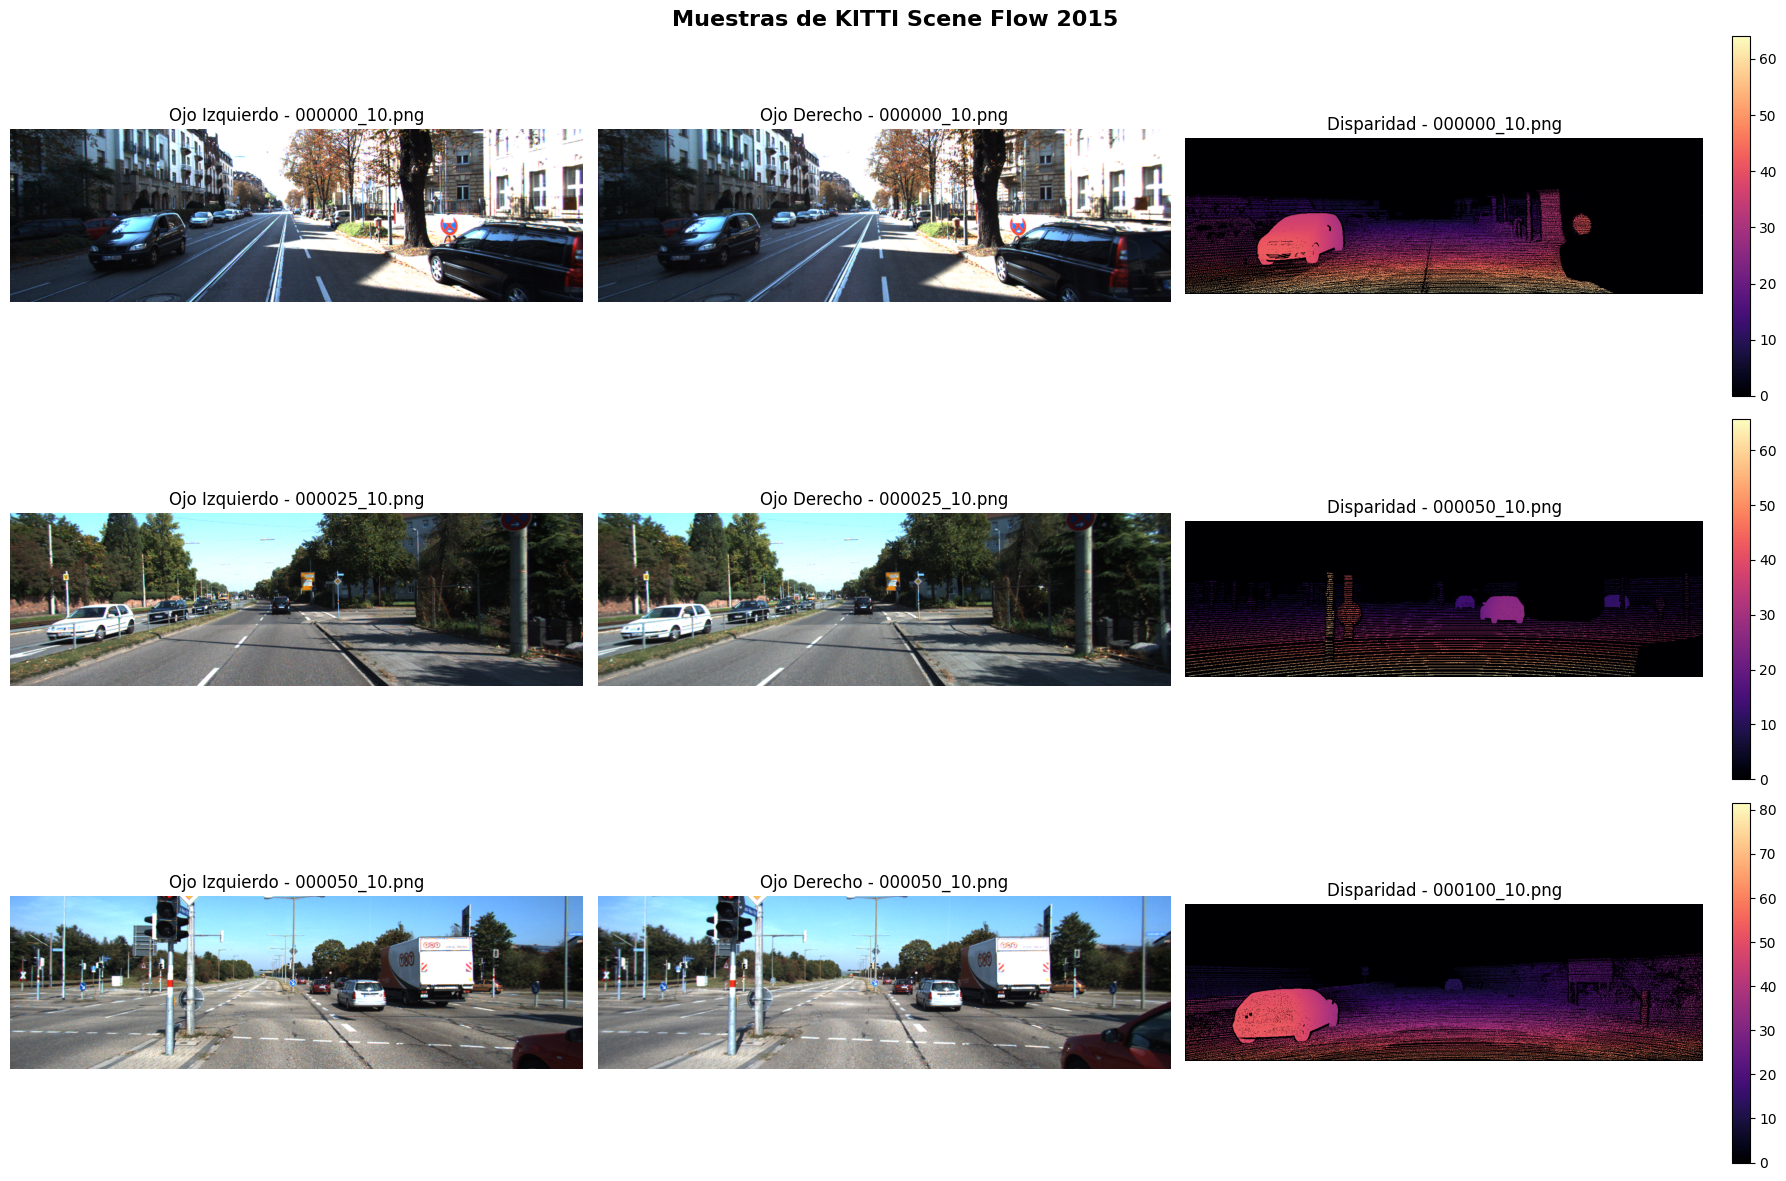


Visualización guardada en results/visualizations/kitti_samples.png


In [ ]:
# Visualizar muestras de KITTI: par estereoscópico + mapa de disparidad
if 'train_left' in kitti_paths:
    left_images = sorted(glob.glob(os.path.join(kitti_paths['train_left'], '*.png')))
    right_images = sorted(glob.glob(os.path.join(kitti_paths['train_right'], '*.png')))
    disp_images = sorted(glob.glob(os.path.join(kitti_paths['train_disp'], '*.png')))

    print(f'Total de pares estereoscópicos de entrenamiento: {len(left_images)}')
    print(f'Total de mapas de disparidad: {len(disp_images)}')
    print(f'Resolución: verificando...')

    # Mostrar 3 ejemplos
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    fig.suptitle('Muestras de KITTI Scene Flow 2015', fontsize=16, fontweight='bold')

    for i in range(3):
        idx = i * 50  # Muestrear cada 50 imágenes
        if idx < len(left_images):
            # Ojo izquierdo
            img_l = Image.open(left_images[idx])
            axes[i, 0].imshow(img_l)
            axes[i, 0].set_title(f'Ojo Izquierdo - {os.path.basename(left_images[idx])}')
            axes[i, 0].axis('off')
            if i == 0:
                print(f'Resolución de imágenes: {img_l.size[0]}x{img_l.size[1]} px')

            # Ojo derecho
            img_r = Image.open(right_images[idx])
            axes[i, 1].imshow(img_r)
            axes[i, 1].set_title(f'Ojo Derecho - {os.path.basename(right_images[idx])}')
            axes[i, 1].axis('off')

            # Mapa de disparidad
            if idx < len(disp_images):
                disp = np.array(Image.open(disp_images[idx])).astype(np.float32) / 256.0
                im = axes[i, 2].imshow(disp, cmap='magma')
                axes[i, 2].set_title(f'Disparidad - {os.path.basename(disp_images[idx])}')
                axes[i, 2].axis('off')
                plt.colorbar(im, ax=axes[i, 2], fraction=0.046)

    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, 'results/visualizations/kitti_samples.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('\nVisualización guardada en results/visualizations/kitti_samples.png')
else:
    print('Primero ejecuta las celdas anteriores para localizar KITTI.')

## 3. Descarga del Dataset 3D Visual Illusion Depth Estimation

Este dataset se descarga directamente desde HuggingFace.
Contiene ~3,000 escenas y ~200,000 imágenes con 5 tipos de ilusión:
inpainting, picture, replay, holography y mirror.

**IMPORTANTE:** Necesitas tu token de HuggingFace para la autenticación.

In [ ]:
# Instalar la librería de HuggingFace
!pip install -q datasets huggingface_hub

print('Librerías de HuggingFace instaladas.')

Librerías de HuggingFace instaladas.


In [ ]:
# Autenticación segura con HuggingFace
from huggingface_hub import login
import getpass

HF_TOKEN = getpass.getpass("Pega tu token de HuggingFace: ")
login(token=HF_TOKEN)
print('Autenticación exitosa con HuggingFace.')

Pega tu token de HuggingFace: ··········
Autenticación exitosa con HuggingFace.


In [ ]:
# Limpiar caché de HuggingFace para liberar disco
!rm -rf /root/.cache/huggingface/
!rm -rf /tmp/hf_*
print('Caché limpiada. Espacio liberado.')
!df -h /

Caché limpiada. Espacio liberado.
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   70G  39% /


In [ ]:
# Explorar el dataset en modo STREAMING (no descarga todo al disco)
from datasets import load_dataset

print('Cargando dataset de ilusiones en modo streaming...')
print('(No descarga todo, solo lee lo que necesitamos)\n')

illusion_stream = load_dataset(
    'AdamYao/3D_Visual_Illusion_Depth_Estimation',
    split='train',
    streaming=True,
    trust_remote_code=True
)

# Tomar solo 5 muestras para explorar la estructura
preview_samples = []
for i, sample in enumerate(illusion_stream):
    preview_samples.append(sample)
    if i >= 4:
        break

print(f'Preview cargado: {len(preview_samples)} muestras')
print(f'Columnas disponibles:')
for col in preview_samples[0].keys():
    print(f'  - {col}')
print(f'\nClaves de ejemplo:')
for s in preview_samples:
    print(f'  {s.get("__key__", "N/A")}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AdamYao/3D_Visual_Illusion_Depth_Estimation' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AdamYao/3D_Visual_Illusion_Depth_Estimation' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Cargando dataset de ilusiones en modo streaming...
(No descarga todo, solo lee lo que necesitamos)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Preview cargado: 5 muestras
Columnas disponibles:
  - png
  - __key__
  - __url__

Claves de ejemplo:
  fooling-3d_2/right/video10/Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder/frame_1017
  fooling-3d_2/right/video10/Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder/frame_0634
  fooling-3d_2/right/video10/Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder/frame_1127
  fooling-3d_2/right/video10/Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder/frame_0424
  fooling-3d_2/right/video10/Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder/frame_0260


In [ ]:
# Explorar los tipos de ilusión disponibles
print('Analizando tipos de ilusión en el preview...')
print('=' * 50)

keys = [item['__key__'] for item in preview_samples]

categories = set()
for key in keys:
    parts = key.split('/')
    if len(parts) > 1:
        categories.add(parts[0])

print(f'\nCategorías encontradas en el preview:')
for cat in sorted(categories):
    count = sum(1 for k in keys if k.startswith(cat))
    print(f'  {cat}: {count} muestras')

Analizando tipos de ilusión en el preview...

Categorías encontradas en el preview:
  fooling-3d_2: 5 muestras


In [ ]:
# Descargar solo 500 imágenes usando streaming
from PIL import Image
import pandas as pd

ILLUSION_SAVE_PATH = os.path.join(ILLUSION_RAW, 'images')
os.makedirs(ILLUSION_SAVE_PATH, exist_ok=True)

print('Descargando 500 imágenes del dataset de ilusiones (streaming)...')
print(f'Guardando directamente en Drive: {ILLUSION_SAVE_PATH}\n')

illusion_stream = load_dataset(
    'AdamYao/3D_Visual_Illusion_Depth_Estimation',
    split='train',
    streaming=True,
    trust_remote_code=True
)

metadata_list = []
saved_count = 0
target_count = 500

for idx, sample in enumerate(illusion_stream):
    if saved_count >= target_count:
        break

    if 'png' in sample and sample['png'] is not None:
        key = sample.get('__key__', f'sample_{idx}')
        safe_name = key.replace('/', '_').replace('\\', '_')
        filename = f'{safe_name}.png'
        filepath = os.path.join(ILLUSION_SAVE_PATH, filename)

        img = sample['png']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img.save(filepath)

        metadata_list.append({
            'index': idx,
            'key': key,
            'filename': filename,
            'width': img.size[0],
            'height': img.size[1]
        })
        saved_count += 1

        if saved_count % 50 == 0:
            print(f'  Guardadas {saved_count}/{target_count} imágenes...')

# Guardar metadata
metadata_df = pd.DataFrame(metadata_list)
metadata_csv_path = os.path.join(ILLUSION_RAW, 'illusion_metadata.csv')
metadata_df.to_csv(metadata_csv_path, index=False)

print(f'\nImágenes guardadas: {saved_count}')
print(f'Metadata guardada en: {metadata_csv_path}')
print(f'Espacio usado: {saved_count * 0.5:.0f} MB aprox.')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AdamYao/3D_Visual_Illusion_Depth_Estimation' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AdamYao/3D_Visual_Illusion_Depth_Estimation' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Descargando 500 imágenes del dataset de ilusiones (streaming)...
Guardando directamente en Drive: /content/drive/MyDrive/cognitive-depth-model/data/raw/illusions/images



Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

  Guardadas 50/500 imágenes...
  Guardadas 100/500 imágenes...
  Guardadas 150/500 imágenes...
  Guardadas 200/500 imágenes...
  Guardadas 250/500 imágenes...
  Guardadas 300/500 imágenes...
  Guardadas 350/500 imágenes...
  Guardadas 400/500 imágenes...
  Guardadas 450/500 imágenes...
  Guardadas 500/500 imágenes...

Imágenes guardadas: 500
Metadata guardada en: /content/drive/MyDrive/cognitive-depth-model/data/raw/illusions/illusion_metadata.csv
Espacio usado: 250 MB aprox.


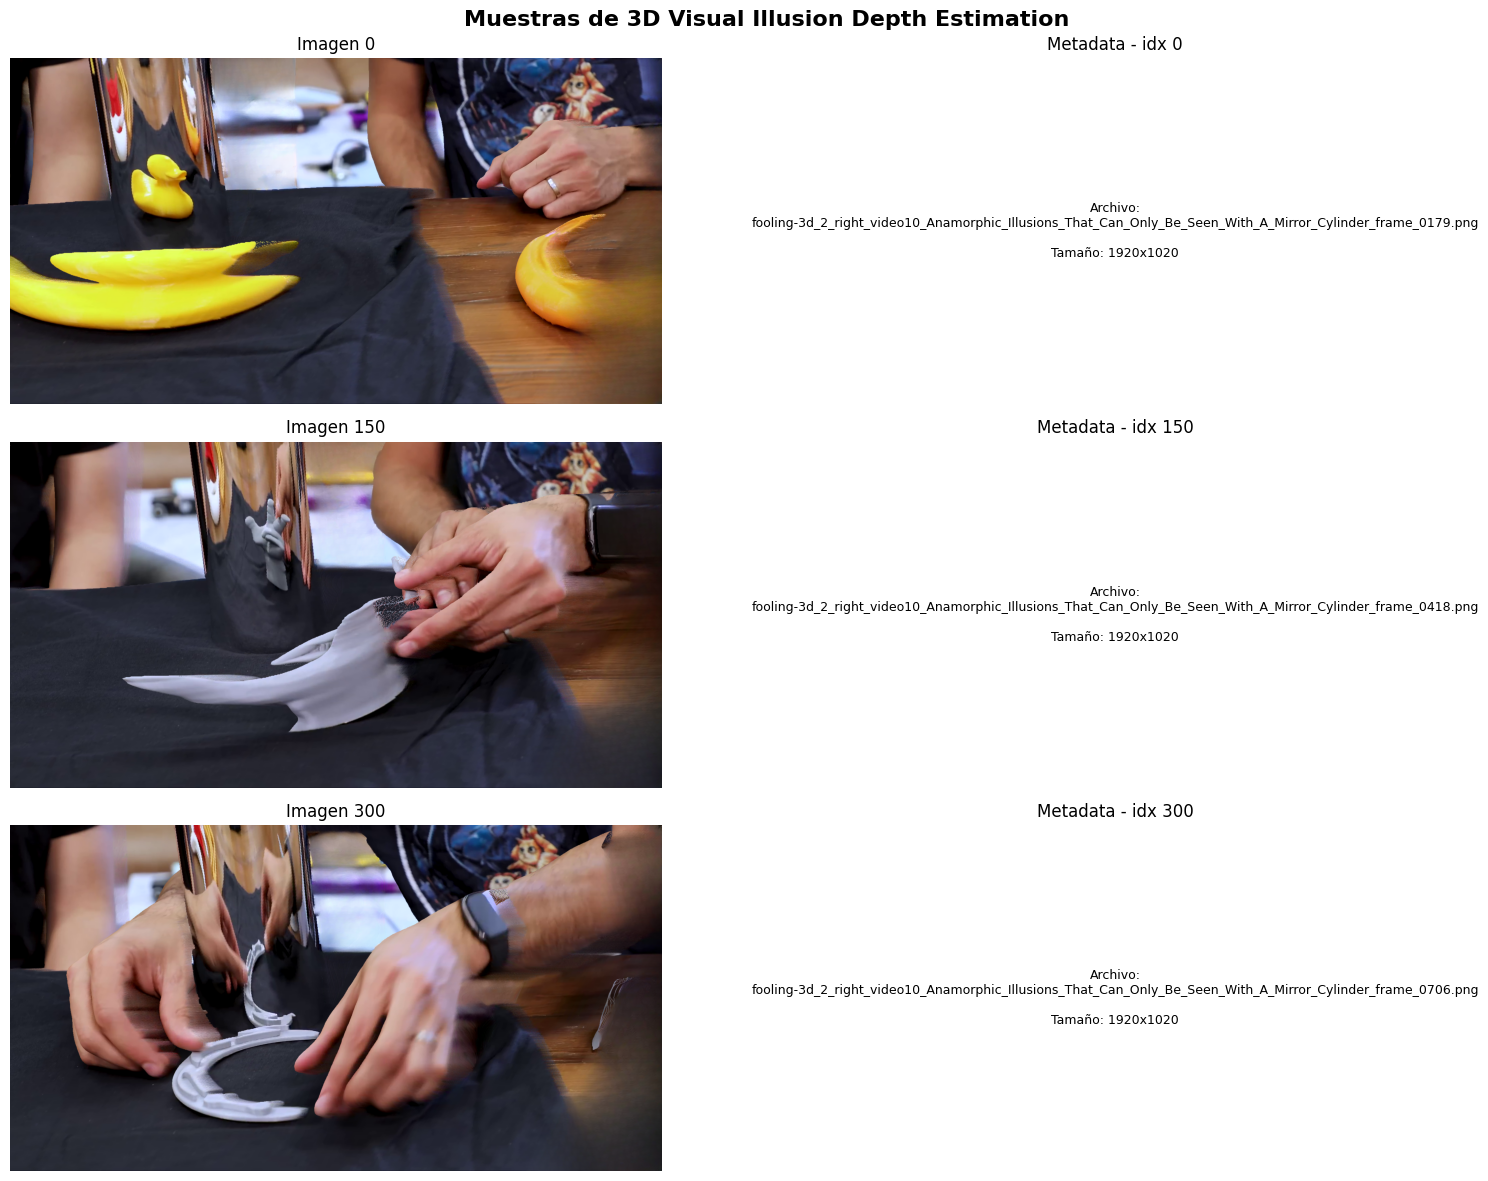

Visualización guardada en results/visualizations/illusion_samples.png


In [ ]:
# Visualizar muestras del dataset de ilusiones (desde Drive)
illusion_files = sorted(glob.glob(os.path.join(ILLUSION_SAVE_PATH, '*.png')))

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Muestras de 3D Visual Illusion Depth Estimation', fontsize=16, fontweight='bold')

for i in range(3):
    idx = i * 150
    if idx < len(illusion_files):
        img = Image.open(illusion_files[idx])
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Imagen {idx}')
        axes[i, 0].axis('off')

        fname = os.path.basename(illusion_files[idx])
        axes[i, 1].text(0.5, 0.5, f'Archivo:\n{fname}\n\nTamaño: {img.size[0]}x{img.size[1]}',
                        ha='center', va='center', fontsize=9,
                        wrap=True, transform=axes[i, 1].transAxes)
        axes[i, 1].set_title(f'Metadata - idx {idx}')
        axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/visualizations/illusion_samples.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Visualización guardada en results/visualizations/illusion_samples.png')

## 4. Resumen de Datos Disponibles y Creación de Splits

Según el diseño de la tesis (Tabla 2), la distribución es:

| Conjunto | KITTI | Illusion | Total |
|---|---|---|---|
| Entrenamiento | 280 | 300 | 580 |
| Prueba | 120 | 100 | 220 |
| Validación (humanos) | 100 | 100 | 200 |

In [ ]:
# Resumen de datos disponibles
print('=' * 60)
print('RESUMEN DE DATOS DISPONIBLES')
print('=' * 60)

# KITTI
if 'train_left' in kitti_paths:
    n_kitti_train = len(os.listdir(kitti_paths['train_left']))
    n_kitti_disp = len(os.listdir(kitti_paths['train_disp'])) if 'train_disp' in kitti_paths else 0
    n_kitti_test = len(os.listdir(kitti_paths['test_left'])) if 'test_left' in kitti_paths else 0
    print(f'\nKITTI Scene Flow 2015:')
    print(f'  Entrenamiento: {n_kitti_train} pares estereoscópicos')
    print(f'  Mapas de disparidad: {n_kitti_disp}')
    print(f'  Prueba: {n_kitti_test} pares estereoscópicos')

# Illusions
if os.path.exists(ILLUSION_SAVE_PATH):
    n_illusion = len(glob.glob(os.path.join(ILLUSION_SAVE_PATH, '*.png')))
    print(f'\n3D Visual Illusion Depth Estimation:')
    print(f'  Imágenes descargadas: {n_illusion}')

print(f'\n' + '=' * 60)
print('DISTRIBUCIÓN PLANIFICADA (Tesis - Tabla 2)')
print('=' * 60)
print(f'  Entrenamiento: 280 KITTI + 300 Illusion = 580')
print(f'  Prueba:        120 KITTI + 100 Illusion = 220')
print(f'  Validación:    100 KITTI + 100 Illusion = 200')
print(f'  Total:         500 KITTI + 500 Illusion = 1000')

RESUMEN DE DATOS DISPONIBLES

KITTI Scene Flow 2015:
  Entrenamiento: 400 pares estereoscópicos
  Mapas de disparidad: 200
  Prueba: 400 pares estereoscópicos

3D Visual Illusion Depth Estimation:
  Imágenes descargadas: 500

DISTRIBUCIÓN PLANIFICADA (Tesis - Tabla 2)
  Entrenamiento: 280 KITTI + 300 Illusion = 580
  Prueba:        120 KITTI + 100 Illusion = 220
  Validación:    100 KITTI + 100 Illusion = 200
  Total:         500 KITTI + 500 Illusion = 1000


In [ ]:
# Crear los splits de KITTI según la tesis
import json
import random

random.seed(42)
np.random.seed(42)

SPLITS_PATH = os.path.join(PROJECT_ROOT, 'data/splits')
os.makedirs(SPLITS_PATH, exist_ok=True)

if 'train_left' in kitti_paths:
    # Obtener lista de IDs de escenas de entrenamiento KITTI
    kitti_train_files = sorted(glob.glob(os.path.join(kitti_paths['train_left'], '*.png')))
    kitti_train_ids = [os.path.splitext(os.path.basename(f))[0] for f in kitti_train_files]

    # Solo las que tienen mapa de disparidad
    if 'train_disp' in kitti_paths:
        disp_files = sorted(glob.glob(os.path.join(kitti_paths['train_disp'], '*.png')))
        disp_ids = set(os.path.splitext(os.path.basename(f))[0] for f in disp_files)
        kitti_with_disp = [id for id in kitti_train_ids if id in disp_ids]
    else:
        kitti_with_disp = kitti_train_ids

    print(f'Escenas KITTI con disparidad disponible: {len(kitti_with_disp)}')

    # Mezclar y dividir
    shuffled = kitti_with_disp.copy()
    random.shuffle(shuffled)

    # Según la tesis: 280 train, 120 test (del training set con disparidad)
    kitti_split_train = shuffled[:280] if len(shuffled) >= 280 else shuffled[:int(len(shuffled)*0.7)]
    kitti_split_test = shuffled[280:400] if len(shuffled) >= 400 else shuffled[int(len(shuffled)*0.7):]

    # Del test set original de KITTI: 100 para validación con humanos
    if 'test_left' in kitti_paths:
        kitti_test_files = sorted(glob.glob(os.path.join(kitti_paths['test_left'], '*.png')))
        kitti_test_ids = [os.path.splitext(os.path.basename(f))[0] for f in kitti_test_files]
        random.shuffle(kitti_test_ids)
        kitti_split_val = kitti_test_ids[:100]
    else:
        kitti_split_val = []

    # Guardar splits
    splits = {
        'kitti_train': kitti_split_train,
        'kitti_test': kitti_split_test,
        'kitti_validation': kitti_split_val,
        'seed': 42,
        'description': 'Splits de KITTI según Tabla 2 de la tesis'
    }

    splits_file = os.path.join(SPLITS_PATH, 'kitti_splits.json')
    with open(splits_file, 'w') as f:
        json.dump(splits, f, indent=2)

    print(f'\nSplits de KITTI creados:')
    print(f'  Train:      {len(kitti_split_train)} escenas')
    print(f'  Test:       {len(kitti_split_test)} escenas')
    print(f'  Validación: {len(kitti_split_val)} escenas')
    print(f'\nGuardado en: {splits_file}')

Escenas KITTI con disparidad disponible: 200

Splits de KITTI creados:
  Train:      140 escenas
  Test:       60 escenas
  Validación: 100 escenas

Guardado en: /content/drive/MyDrive/cognitive-depth-model/data/splits/kitti_splits.json


In [ ]:
# Crear los splits del dataset de ilusiones
if os.path.exists(ILLUSION_SAVE_PATH):
    illusion_files = sorted(glob.glob(os.path.join(ILLUSION_SAVE_PATH, '*.png')))
    illusion_ids = [os.path.splitext(os.path.basename(f))[0] for f in illusion_files]

    random.shuffle(illusion_ids)

    # Según la tesis: 300 train, 100 test, 100 validación
    ill_split_train = illusion_ids[:300] if len(illusion_ids) >= 300 else illusion_ids[:int(len(illusion_ids)*0.6)]
    ill_split_test = illusion_ids[300:400] if len(illusion_ids) >= 400 else illusion_ids[int(len(illusion_ids)*0.6):int(len(illusion_ids)*0.8)]
    ill_split_val = illusion_ids[400:500] if len(illusion_ids) >= 500 else illusion_ids[int(len(illusion_ids)*0.8):]

    ill_splits = {
        'illusion_train': ill_split_train,
        'illusion_test': ill_split_test,
        'illusion_validation': ill_split_val,
        'seed': 42,
        'description': 'Splits de Illusion dataset según Tabla 2 de la tesis'
    }

    ill_splits_file = os.path.join(SPLITS_PATH, 'illusion_splits.json')
    with open(ill_splits_file, 'w') as f:
        json.dump(ill_splits, f, indent=2)

    print(f'Splits de Illusion creados:')
    print(f'  Train:      {len(ill_split_train)} imágenes')
    print(f'  Test:       {len(ill_split_test)} imágenes')
    print(f'  Validación: {len(ill_split_val)} imágenes')
    print(f'\nGuardado en: {ill_splits_file}')

Splits de Illusion creados:
  Train:      300 imágenes
  Test:       100 imágenes
  Validación: 100 imágenes

Guardado en: /content/drive/MyDrive/cognitive-depth-model/data/splits/illusion_splits.json


In [ ]:
# Resumen final consolidado
print('=' * 60)
print('NOTEBOOK 02 COMPLETADO')
print('=' * 60)
print()
print('Datasets configurados:')
print(f'  KITTI Scene Flow 2015: explorado y splits creados')
print(f'  3D Visual Illusion:    descargado y splits creados')
print()
print('Archivos generados:')
print(f'  {os.path.join(SPLITS_PATH, "kitti_splits.json")}')
print(f'  {os.path.join(SPLITS_PATH, "illusion_splits.json")}')
print(f'  {os.path.join(PROJECT_ROOT, "results/visualizations/kitti_samples.png")}')
print(f'  {os.path.join(PROJECT_ROOT, "results/visualizations/illusion_samples.png")}')
print()
print('Siguiente paso: Notebook 03 - Pipeline de Preprocesamiento (Fases 1-6)')

NOTEBOOK 02 COMPLETADO

Datasets configurados:
  KITTI Scene Flow 2015: explorado y splits creados
  3D Visual Illusion:    descargado y splits creados

Archivos generados:
  /content/drive/MyDrive/cognitive-depth-model/data/splits/kitti_splits.json
  /content/drive/MyDrive/cognitive-depth-model/data/splits/illusion_splits.json
  /content/drive/MyDrive/cognitive-depth-model/results/visualizations/kitti_samples.png
  /content/drive/MyDrive/cognitive-depth-model/results/visualizations/illusion_samples.png

Siguiente paso: Notebook 03 - Pipeline de Preprocesamiento (Fases 1-6)
